# 02. Análisis Exploratorio de Datos (EDA)
## TFM — Estimación de Precios de la Electricidad y Arbitraje Energético
### Jaime Cremades Castelló | CUNEF Universidad | 2026

Análisis exploratorio del dataset de modelado. Cubre:
- Distribución y estadísticos del precio eléctrico español
- Patrones temporales: horarios, semanales y estacionales
- Crisis energética 2021-2022 y precios negativos
- Mix de generación y ratio renovable
- Correlaciones entre variables
- Validación de variables previstas

**Input:** `dataset_final_clean.csv`


# 4.5 Análisis Exploratorio de Datos (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('dataset_final_clean.csv')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.sort_values('datetime').set_index('datetime')
df['year'] = df.index.year

print(f'Registros: {len(df):,}')
print(f'Periodo: {df.index.min().date()} -> {df.index.max().date()}')
print(f'Variables: {df.shape[1]}')
print()
print(df.dtypes)
print()
print(df.describe().round(2))

Registros: 53,585
Periodo: 2020-01-01 -> 2026-02-28
Variables: 43

hour                            int64
dayofweek                       int64
month                           int64
price_spain                   float64
Prevista                      float64
Programada                    float64
Real                          float64
error_demanda                 float64
temperature                   float64
wind_speed                    float64
wind_generation               float64
solar_generation              float64
hidraulica_generation         float64
nuclear_generation            float64
ciclo_combinado_generation    float64
generacion_total              float64
net_imports                   float64
consumo_bombeo                float64
turbinacion_bombeo            float64
bombeo_neto                   float64
renovable_ratio               float64
gas_ratio                     float64
nuclear_ratio                 float64
base_load                     float64
gap_no_renovable     

## 1. Valores nulos


In [2]:
nulos = df.isna().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos — dataset limpio')

Valores nulos por columna:
Sin valores nulos — dataset limpio


## 2. Estadísticas descriptivas del precio


In [3]:
desc = df['price_spain'].describe(percentiles=[.05, .25, .5, .75, .95])
print(desc.round(2))
print(f'\nPrecios negativos: {(df["price_spain"] < 0).sum()} ({(df["price_spain"] < 0).mean()*100:.1f}%)')
print(f'Precios > 200 euros/MWh: {(df["price_spain"] > 200).sum()} ({(df["price_spain"] > 200).mean()*100:.1f}%)')

count    53585.00
mean        87.51
std         67.44
min         -5.00
5%           2.10
25%         35.70
50%         79.00
75%        120.76
95%        217.65
max        651.00
Name: price_spain, dtype: float64

Precios negativos: 511 (1.0%)
Precios > 200 euros/MWh: 3760 (7.0%)


## 3. Evolución temporal del precio


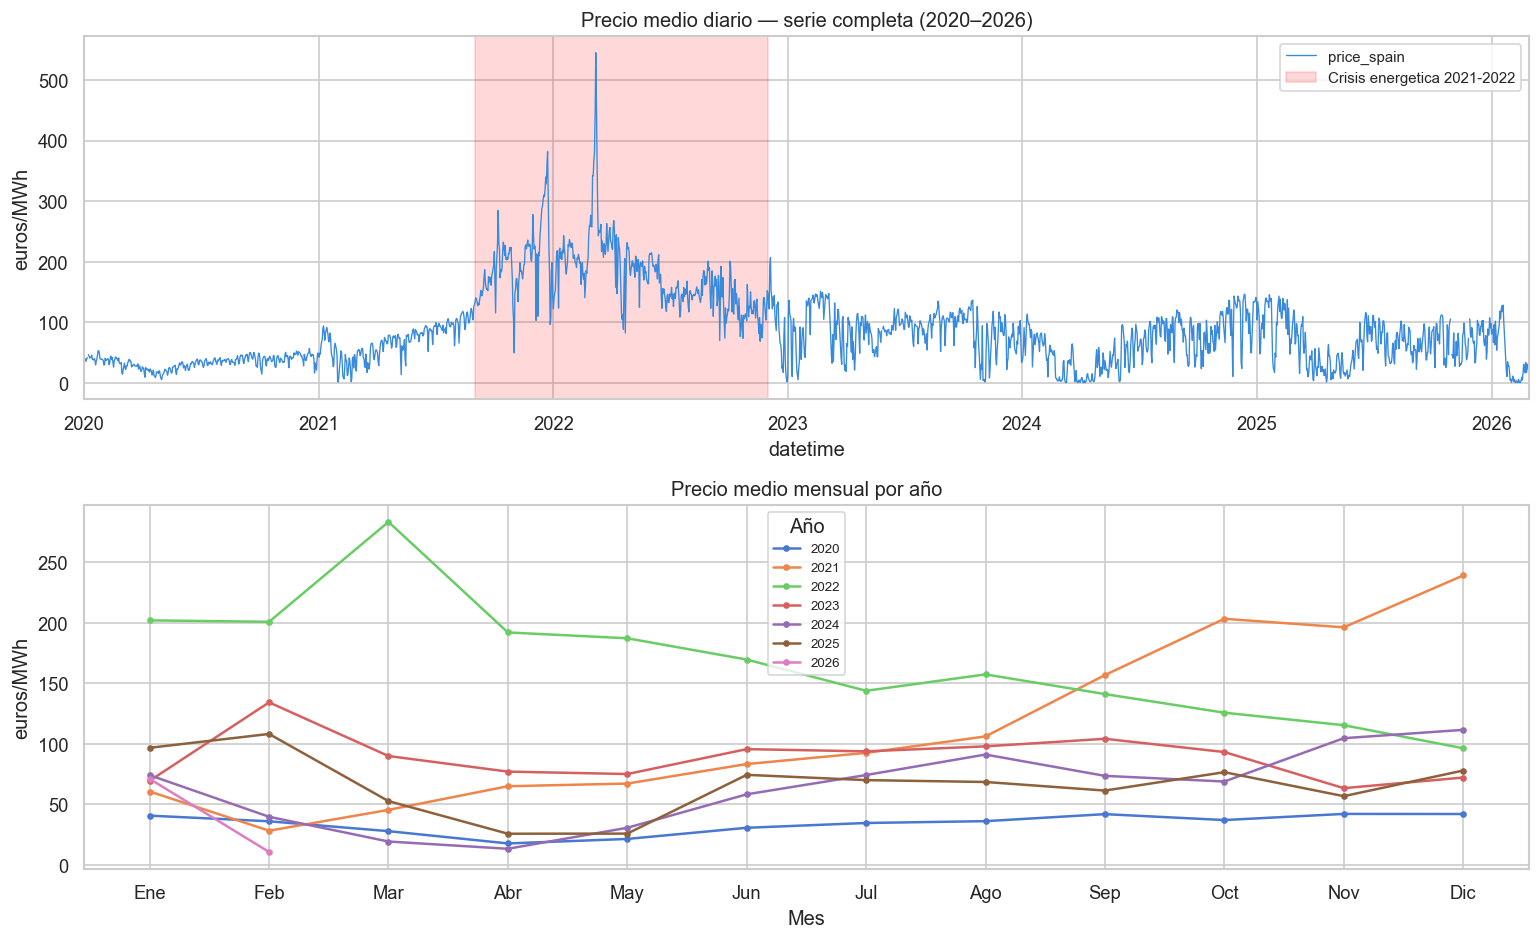

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

df['price_spain'].resample('D').mean().plot(ax=axes[0], color='#378ADD', linewidth=0.8)
axes[0].set_title('Precio medio diario — serie completa (2020–2026)', fontsize=12)
axes[0].set_ylabel('euros/MWh')
axes[0].axvspan('2021-09-01', '2022-12-01', alpha=0.15, color='red', label='Crisis energetica 2021-2022')
axes[0].legend(fontsize=9)

pivot_anual = df.groupby(['year', 'month'])['price_spain'].mean().unstack(0)
pivot_anual.plot(ax=axes[1], marker='o', markersize=3, linewidth=1.5)
axes[1].set_title('Precio medio mensual por año', fontsize=12)
axes[1].set_ylabel('euros/MWh')
axes[1].set_xlabel('Mes')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].legend(title='Año', fontsize=8)

plt.tight_layout()
plt.savefig('fig1_evolucion_precio.png', bbox_inches='tight')
plt.show()

## 4. Distribución del precio y precios negativos


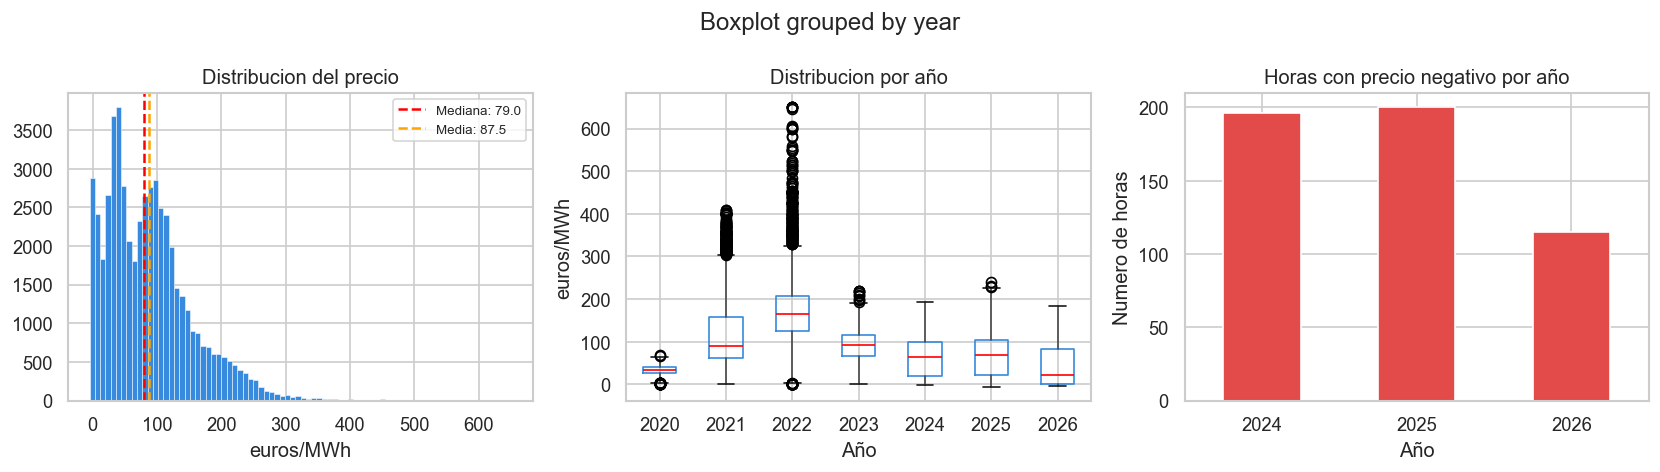

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['price_spain'], bins=80, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].axvline(df['price_spain'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["price_spain"].median():.1f}')
axes[0].axvline(df['price_spain'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Media: {df["price_spain"].mean():.1f}')
axes[0].set_title('Distribucion del precio')
axes[0].set_xlabel('euros/MWh')
axes[0].legend(fontsize=8)

df.boxplot(column='price_spain', by='year', ax=axes[1],
           boxprops=dict(color='#378ADD'),
           medianprops=dict(color='red'))
axes[1].set_title('Distribucion por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('euros/MWh')
plt.sca(axes[1])
plt.title('Distribucion por año')

neg_por_anio = df[df['price_spain'] < 0].groupby('year').size()
neg_por_anio.plot(kind='bar', ax=axes[2], color='#E24B4A', edgecolor='white')
axes[2].set_title('Horas con precio negativo por año')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Numero de horas')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig2_distribucion_precio.png', bbox_inches='tight')
plt.show()

## 5. Outliers


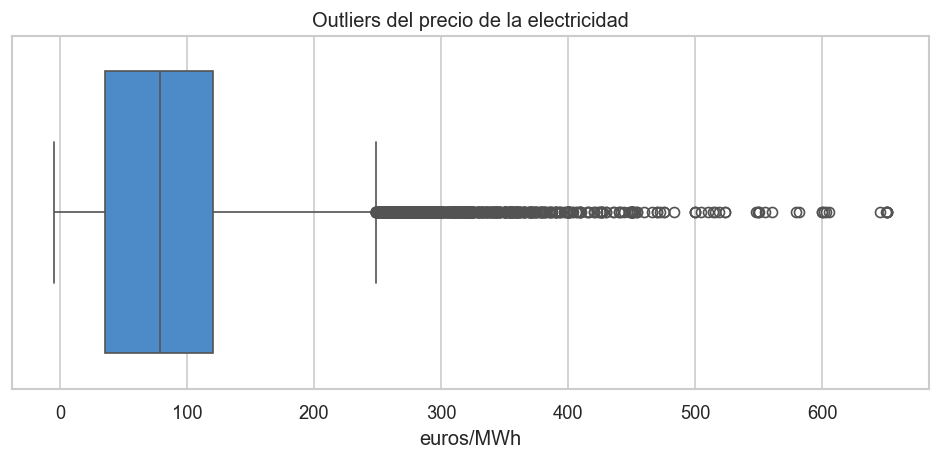

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df['price_spain'], ax=ax, color='#378ADD')
ax.set_title('Outliers del precio de la electricidad')
ax.set_xlabel('euros/MWh')
plt.tight_layout()
plt.savefig('fig3_outliers.png', bbox_inches='tight')
plt.show()

## 6. Estacionalidad


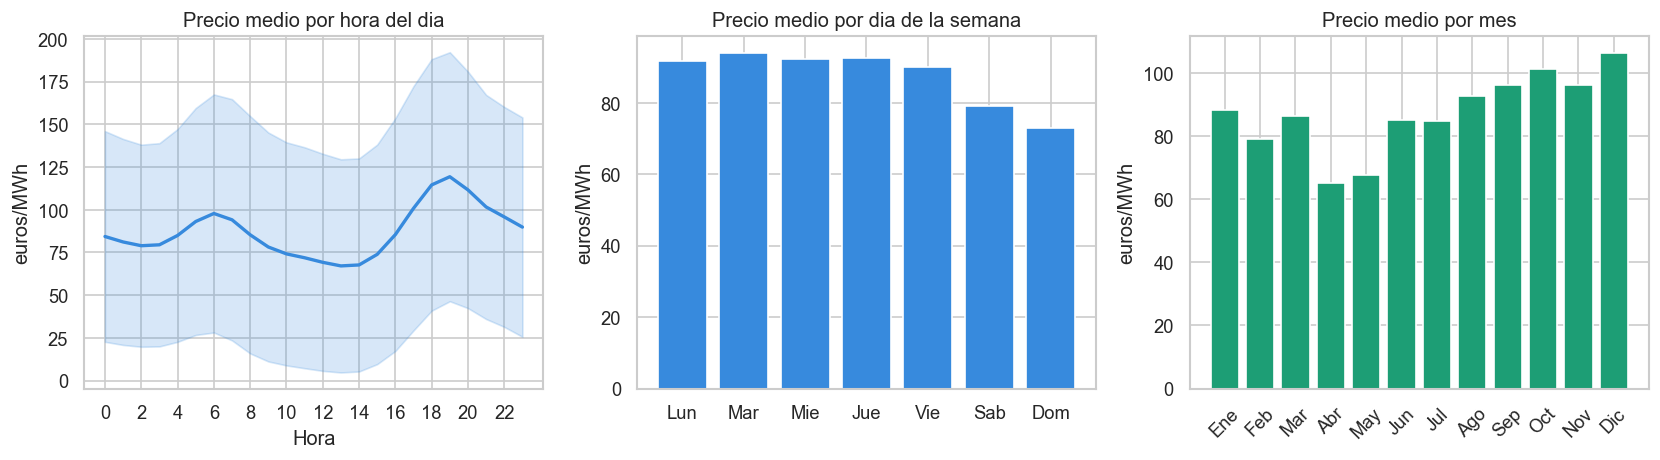

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

hora_mean = df.groupby('hour')['price_spain'].mean()
hora_std  = df.groupby('hour')['price_spain'].std()
axes[0].plot(hora_mean.index, hora_mean.values, color='#378ADD', linewidth=2)
axes[0].fill_between(hora_mean.index, hora_mean - hora_std, hora_mean + hora_std,
                     alpha=0.2, color='#378ADD')
axes[0].set_title('Precio medio por hora del dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('euros/MWh')
axes[0].set_xticks(range(0, 24, 2))

dia_mean = df.groupby('dayofweek')['price_spain'].mean()
dias = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
axes[1].bar(dias, dia_mean.values, color='#378ADD', edgecolor='white')
axes[1].set_title('Precio medio por dia de la semana')
axes[1].set_ylabel('euros/MWh')

mes_mean = df.groupby('month')['price_spain'].mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[2].bar(meses, mes_mean.values, color='#1D9E75', edgecolor='white')
axes[2].set_title('Precio medio por mes')
axes[2].set_ylabel('euros/MWh')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig4_estacionalidad.png', bbox_inches='tight')
plt.show()

## 7. Heatmap precio medio hora x mes


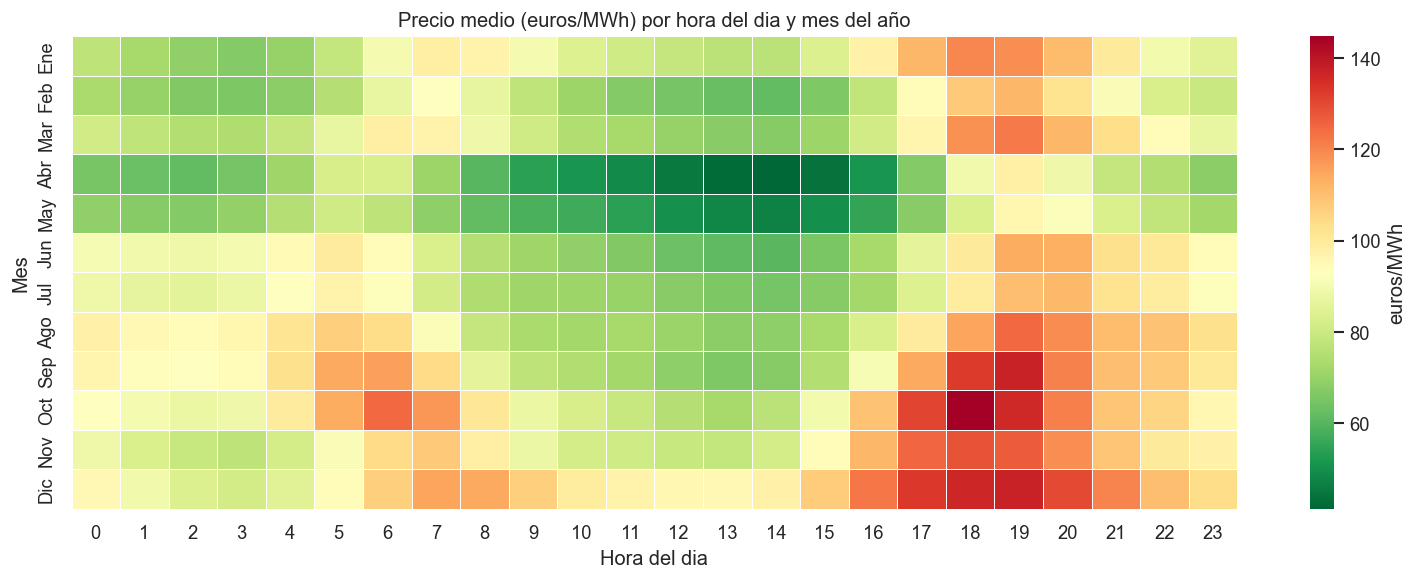

In [8]:
pivot = df.groupby(['month', 'hour'])['price_spain'].mean().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=False,
            xticklabels=range(0,24),
            yticklabels=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'],
            linewidths=0.3, ax=ax, cbar_kws={'label': 'euros/MWh'})
ax.set_title('Precio medio (euros/MWh) por hora del dia y mes del año', fontsize=12)
ax.set_xlabel('Hora del dia')
ax.set_ylabel('Mes')

plt.tight_layout()
plt.savefig('fig5_heatmap_hora_mes.png', bbox_inches='tight')
plt.show()

## 8. Efecto calendario


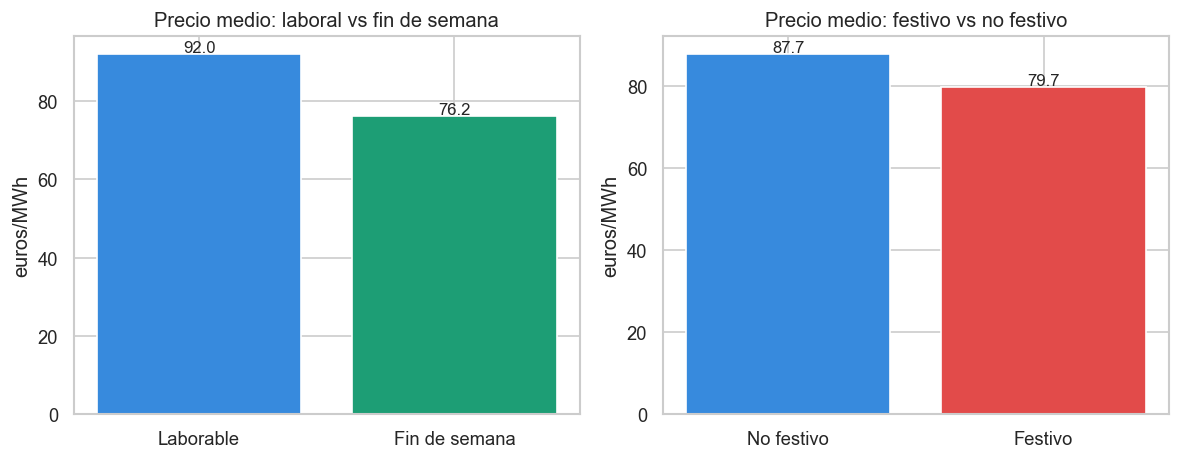

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fds = df.groupby('is_weekend')['price_spain'].mean()
axes[0].bar(['Laborable', 'Fin de semana'], fds.values, color=['#378ADD', '#1D9E75'], edgecolor='white')
axes[0].set_title('Precio medio: laboral vs fin de semana')
axes[0].set_ylabel('euros/MWh')
for i, v in enumerate(fds.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

fest = df.groupby('is_holiday')['price_spain'].mean()
axes[1].bar(['No festivo', 'Festivo'], fest.values, color=['#378ADD', '#E24B4A'], edgecolor='white')
axes[1].set_title('Precio medio: festivo vs no festivo')
axes[1].set_ylabel('euros/MWh')
for i, v in enumerate(fest.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig6_efecto_calendario.png', bbox_inches='tight')
plt.show()

## 9. Generacion por tecnologia


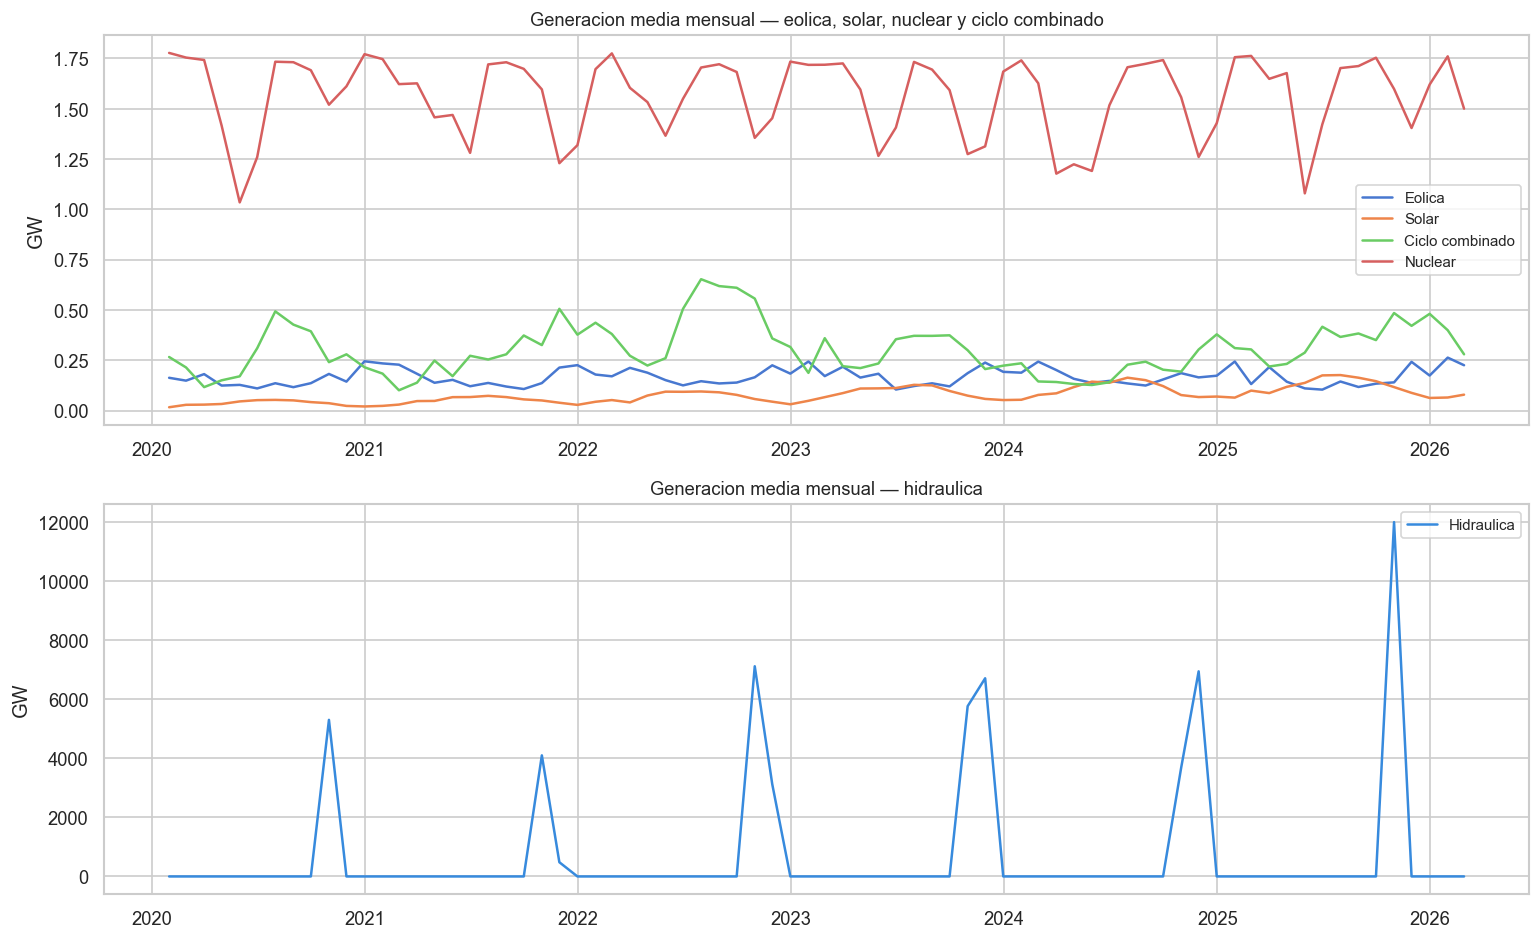

In [10]:
energy_cols = [
    'wind_generation', 'solar_generation',
    'hidraulica_generation', 'nuclear_generation',
    'ciclo_combinado_generation'
]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Gráfico 1: renovables vs ciclo combinado (escala similar)
renovables = ['wind_generation', 'solar_generation', 'ciclo_combinado_generation', 'nuclear_generation']
labels_ren = ['Eolica', 'Solar', 'Ciclo combinado', 'Nuclear']
for col, label in zip(renovables, labels_ren):
    serie = df[col].resample('ME').mean()
    axes[0].plot(serie.index, serie.values / 1000, linewidth=1.5, label=label)
axes[0].set_title('Generacion media mensual — eolica, solar, nuclear y ciclo combinado', fontsize=11)
axes[0].set_ylabel('GW')
axes[0].legend(fontsize=9)

# Gráfico 2: hidráulica por separado
serie_hid = df['hidraulica_generation'].resample('ME').mean()
axes[1].plot(serie_hid.index, serie_hid.values / 1000, color='#378ADD', linewidth=1.5, label='Hidraulica')
axes[1].set_title('Generacion media mensual — hidraulica', fontsize=11)
axes[1].set_ylabel('GW')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_generacion_tecnologia.png', bbox_inches='tight')
plt.show()

In [11]:
print(df['hidraulica_generation'].describe())
print()
print('Valores cero o muy bajos:')
print((df['hidraulica_generation'] < 100).sum(), 'horas con valor < 100')
print()
print('Muestra de valores bajos:')
print(df[df['hidraulica_generation'] < 100]['hidraulica_generation'].head(20))

count    5.358500e+04
mean     7.303606e+05
std      3.913231e+06
min      0.000000e+00
25%      4.324821e+02
50%      7.669196e+02
75%      9.667527e+02
max      4.147423e+07
Name: hidraulica_generation, dtype: float64

Valores cero o muy bajos:
2 horas con valor < 100

Muestra de valores bajos:
datetime
2025-04-28 11:00:00+00:00     0.000000
2025-04-28 12:00:00+00:00    31.021919
Name: hidraulica_generation, dtype: float64


In [12]:
umbral = 5_000_000  # 5 millones MW es claramente anómalo

anomalos = df[df['hidraulica_generation'] > umbral]['hidraulica_generation']
print(f'Valores anómalos (> 5M MW): {len(anomalos)}')
print()
print(anomalos.sort_values(ascending=False).head(20))

Valores anómalos (> 5M MW): 2103

datetime
2022-10-27 11:00:00+00:00    41474233.0
2022-10-27 12:00:00+00:00    41397924.0
2022-10-27 10:00:00+00:00    40889690.0
2022-10-27 13:00:00+00:00    39770164.0
2022-10-27 09:00:00+00:00    38948554.0
2022-10-27 14:00:00+00:00    37672015.0
2023-10-25 12:00:00+00:00    34538433.0
2022-10-27 08:00:00+00:00    34451901.0
2023-10-25 13:00:00+00:00    34272597.0
2023-10-26 18:00:00+00:00    34232837.0
2023-10-25 10:00:00+00:00    34229198.0
2023-10-26 19:00:00+00:00    34181074.0
2025-10-23 08:00:00+00:00    34073906.0
2025-10-23 12:00:00+00:00    34017251.0
2025-10-23 09:00:00+00:00    33992708.0
2023-10-25 09:00:00+00:00    33833578.0
2023-10-26 11:00:00+00:00    33694662.0
2025-10-20 10:00:00+00:00    33669597.0
2025-10-23 10:00:00+00:00    33638725.0
2025-10-23 14:00:00+00:00    33606940.0
Name: hidraulica_generation, dtype: float64


Nuevo maximo: 25,000 MW
Registros corregidos: 2105


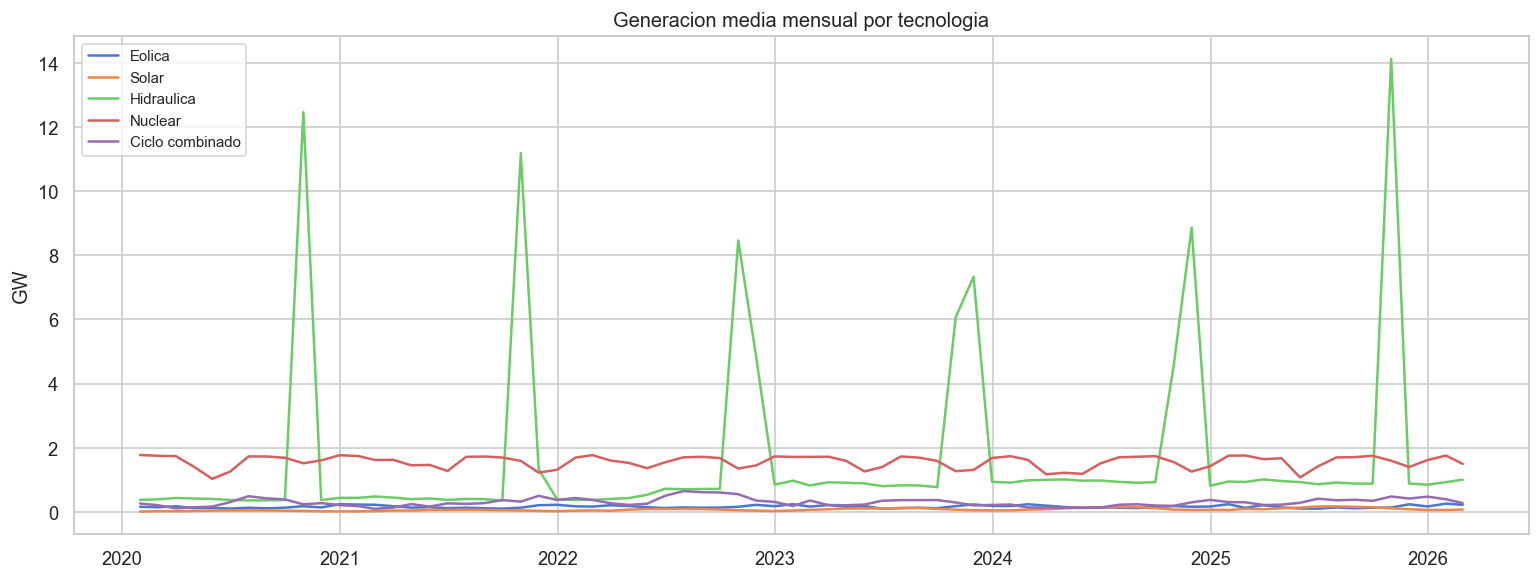

In [13]:
# Corregir anomalias en hidraulica_generation (cambios de hora)
CAP_HIDRAULICA = 25_000  # MW maximo razonable para hidraulica española

df['hidraulica_generation'] = df['hidraulica_generation'].clip(upper=CAP_HIDRAULICA)

print(f'Nuevo maximo: {df["hidraulica_generation"].max():,.0f} MW')
print(f'Registros corregidos: {(df["hidraulica_generation"] == CAP_HIDRAULICA).sum()}')

# Redibujar el grafico
fig, ax = plt.subplots(figsize=(13, 5))
for col, label in zip(energy_cols, ['Eolica','Solar','Hidraulica','Nuclear','Ciclo combinado']):
    serie = df[col].resample('ME').mean()
    ax.plot(serie.index, serie.values / 1000, linewidth=1.5, label=label)

ax.set_title('Generacion media mensual por tecnologia', fontsize=12)
ax.set_ylabel('GW')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig7_generacion_tecnologia.png', bbox_inches='tight')
plt.show()

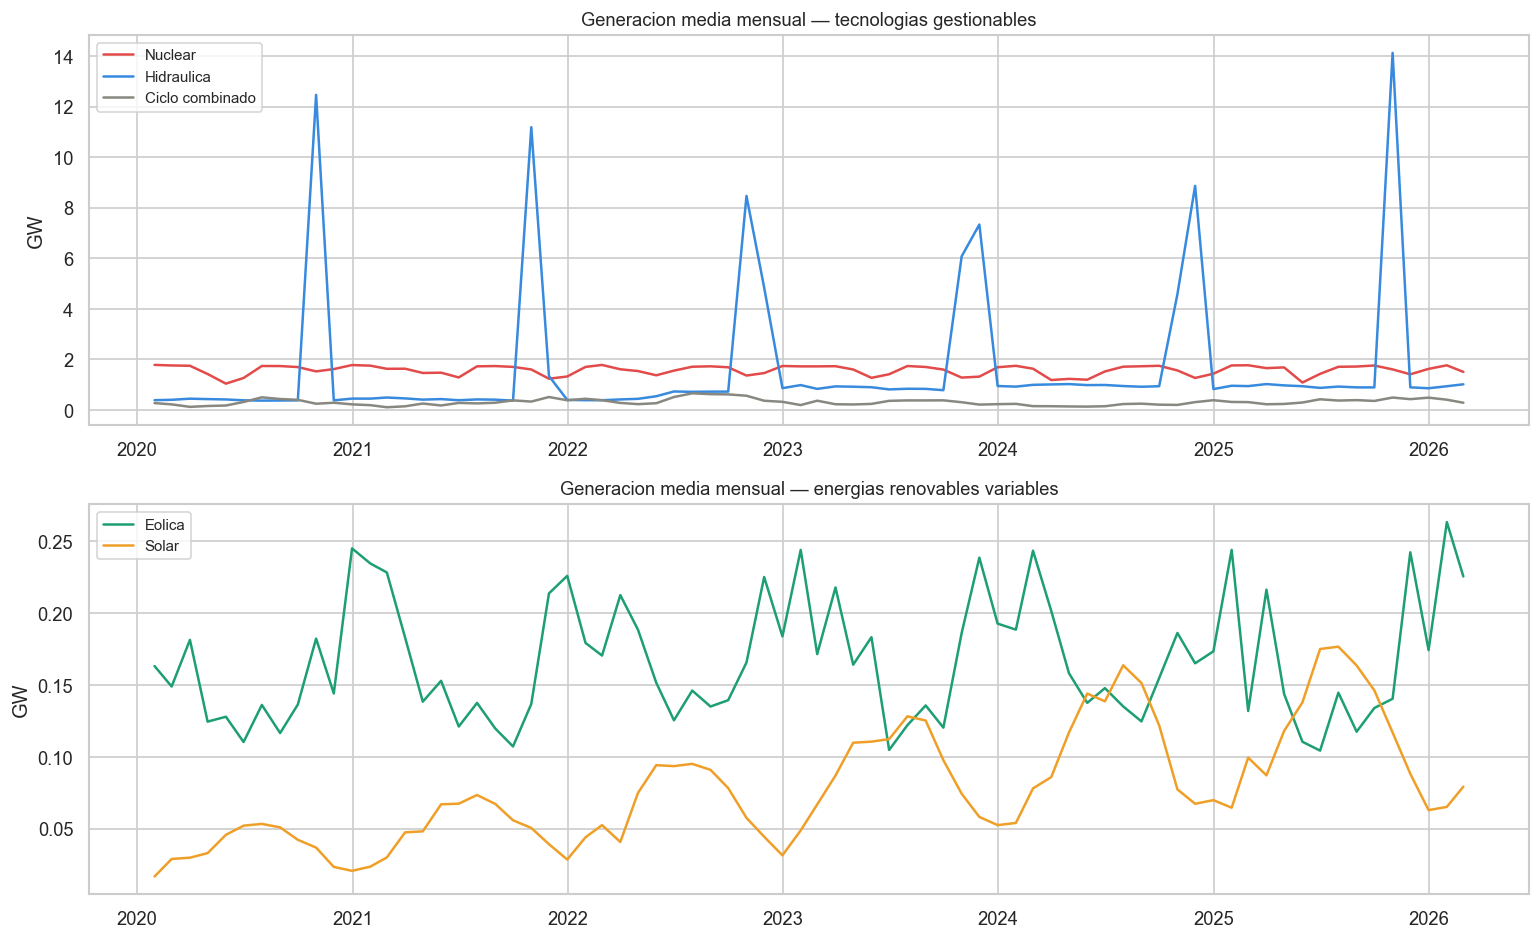

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Subplot 1: tecnologías base y gestionables
for col, label, color in zip(
    ['nuclear_generation', 'hidraulica_generation', 'ciclo_combinado_generation'],
    ['Nuclear', 'Hidraulica', 'Ciclo combinado'],
    ['#E24B4A', '#378ADD', '#888780']
):
    serie = df[col].resample('ME').mean() / 1000
    axes[0].plot(serie.index, serie.values, linewidth=1.5, label=label, color=color)
axes[0].set_title('Generacion media mensual — tecnologias gestionables', fontsize=11)
axes[0].set_ylabel('GW')
axes[0].legend(fontsize=9)

# Subplot 2: renovables variables
for col, label, color in zip(
    ['wind_generation', 'solar_generation'],
    ['Eolica', 'Solar'],
    ['#1D9E75', '#EF9F27']
):
    serie = df[col].resample('ME').mean() / 1000
    axes[1].plot(serie.index, serie.values, linewidth=1.5, label=label, color=color)
axes[1].set_title('Generacion media mensual — energias renovables variables', fontsize=11)
axes[1].set_ylabel('GW')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_generacion_tecnologia.png', bbox_inches='tight')
plt.show()

In [15]:
for col in energy_cols:
    print(f'{col}:')
    print(f'  media={df[col].mean():,.0f}  max={df[col].max():,.0f}  min={df[col].min():,.0f}')
    print()

wind_generation:
  media=166  max=509  min=0

solar_generation:
  media=78  max=922  min=-0

hidraulica_generation:
  media=1,653  max=25,000  min=0

nuclear_generation:
  media=1,564  max=3,049  min=0

ciclo_combinado_generation:
  media=304  max=1,099  min=19



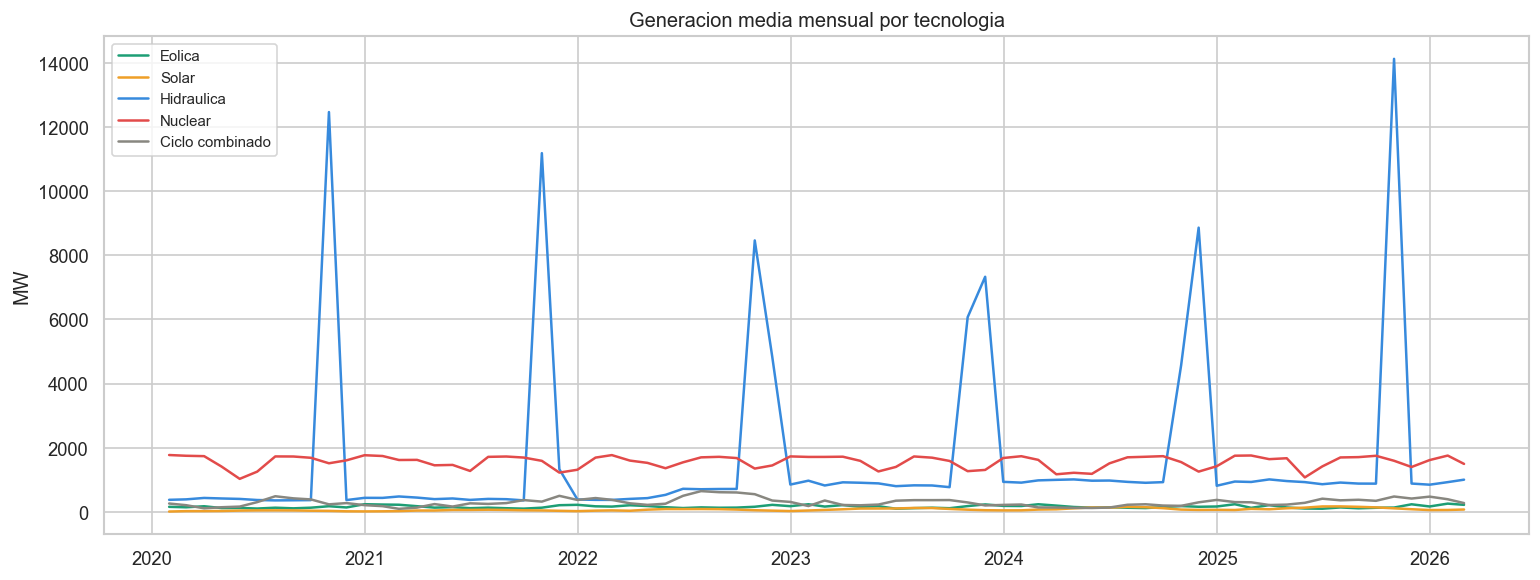

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

for col, label, color in zip(
    energy_cols,
    ['Eolica', 'Solar', 'Hidraulica', 'Nuclear', 'Ciclo combinado'],
    ['#1D9E75', '#EF9F27', '#378ADD', '#E24B4A', '#888780']
):
    serie = df[col].resample('ME').mean()
    ax.plot(serie.index, serie.values, linewidth=1.5, label=label, color=color)

ax.set_title('Generacion media mensual por tecnologia', fontsize=12)
ax.set_ylabel('MW')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_generacion_tecnologia.png', bbox_inches='tight')
plt.show()

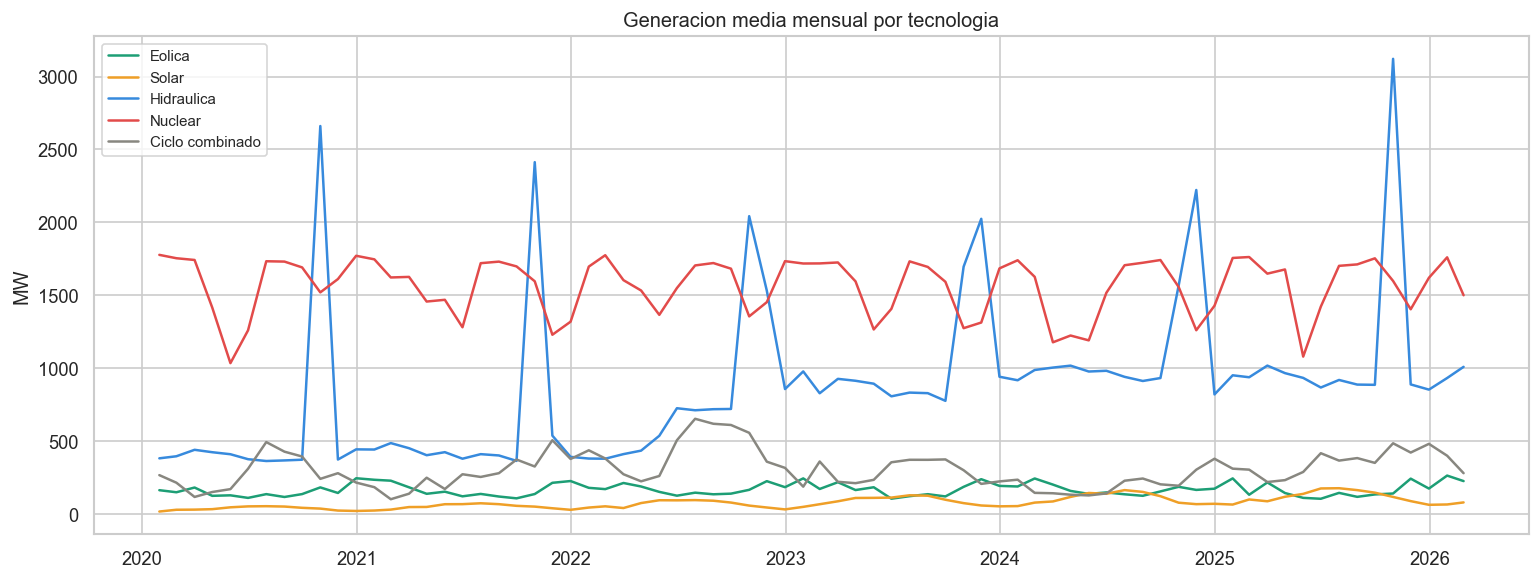

In [17]:
# Filtrar anomalias antes de graficar
CAP = 5000  # MW maximo real para hidraulica horaria

fig, ax = plt.subplots(figsize=(13, 5))

for col, label, color in zip(
    energy_cols,
    ['Eolica', 'Solar', 'Hidraulica', 'Nuclear', 'Ciclo combinado'],
    ['#1D9E75', '#EF9F27', '#378ADD', '#E24B4A', '#888780']
):
    serie = df[col].copy()
    if col == 'hidraulica_generation':
        serie = serie.clip(upper=CAP)
    serie = serie.resample('ME').mean()
    ax.plot(serie.index, serie.values, linewidth=1.5, label=label, color=color)

ax.set_title('Generacion media mensual por tecnologia', fontsize=12)
ax.set_ylabel('MW')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_generacion_tecnologia.png', bbox_inches='tight')
plt.show()

## 10. Ratio renovable vs precio (con conteo por bin)


C:\Users\Jaime Cremades\AppData\Local\Temp\ipykernel_12056\3482227711.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('ren_bin')['price_spain'].agg(['mean','count']).reset_index()


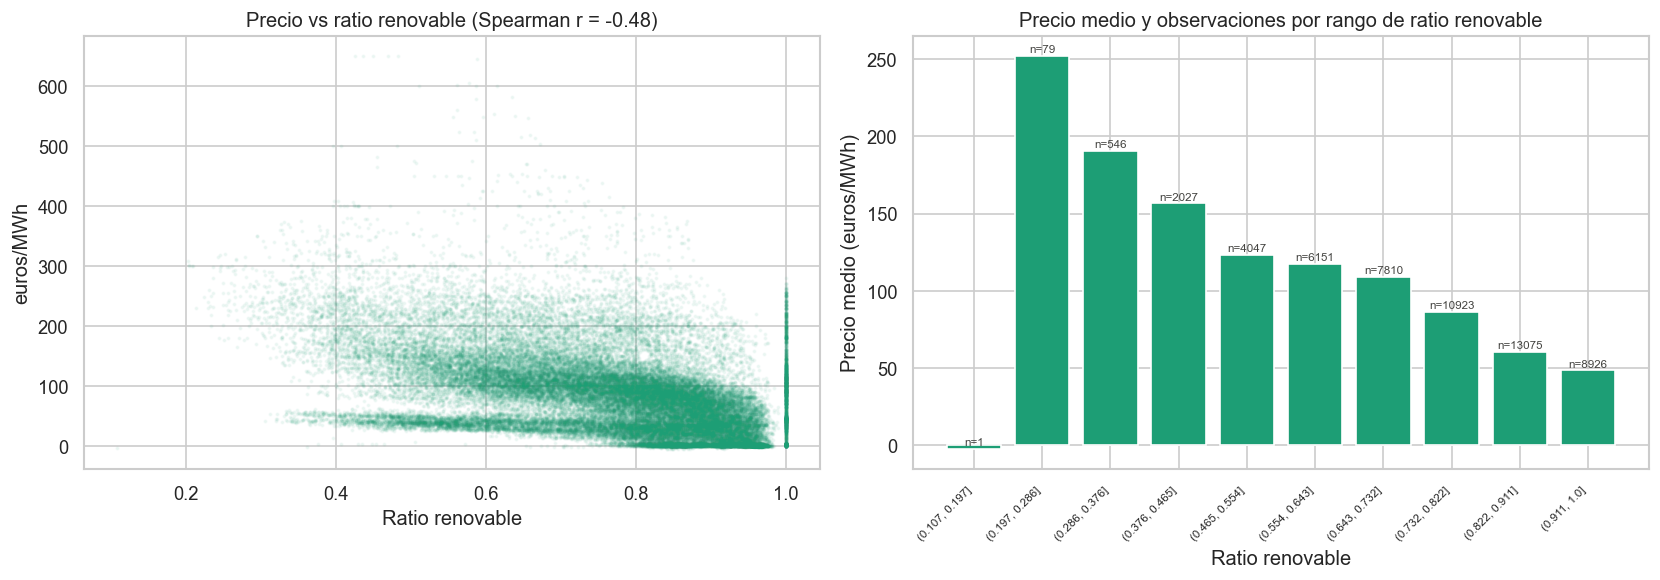

Observaciones por bin:
       ren_bin       mean  count
(0.107, 0.197]  -2.500000      1
(0.197, 0.286] 252.146962     79
(0.286, 0.376] 190.544432    546
(0.376, 0.465] 156.681733   2027
(0.465, 0.554] 123.100095   4047
(0.554, 0.643] 117.486068   6151
(0.643, 0.732] 109.281559   7810
(0.732, 0.822]  86.581630  10923
(0.822, 0.911]  60.701994  13075
  (0.911, 1.0]  48.606769   8926


In [18]:
df['ren_bin'] = pd.cut(df['renovable_ratio'], bins=10)
bin_stats = df.groupby('ren_bin')['price_spain'].agg(['mean','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['renovable_ratio'], df['price_spain'], alpha=0.05, s=2, color='#1D9E75')
corr_ren = df['renovable_ratio'].corr(df['price_spain'], method='spearman')
axes[0].set_title(f'Precio vs ratio renovable (Spearman r = {corr_ren:.2f})')
axes[0].set_xlabel('Ratio renovable')
axes[0].set_ylabel('euros/MWh')

# Barras con conteo
x_labels = [str(b) for b in bin_stats['ren_bin']]
bars = axes[1].bar(range(len(bin_stats)), bin_stats['mean'], color='#1D9E75', edgecolor='white')
axes[1].set_title('Precio medio y observaciones por rango de ratio renovable')
axes[1].set_xlabel('Ratio renovable')
axes[1].set_ylabel('Precio medio (euros/MWh)')
axes[1].set_xticks(range(len(bin_stats)))
axes[1].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7)

# Conteo de observaciones encima de cada barra
for i, (bar, count) in enumerate(zip(bars, bin_stats['count'])):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'n={count}', ha='center', va='bottom', fontsize=7, color='#444441')

plt.tight_layout()
plt.savefig('fig8_renovable_precio.png', bbox_inches='tight')
plt.show()

print('Observaciones por bin:')
print(bin_stats[['ren_bin','mean','count']].to_string(index=False))

## 11. Relacion precio con variables clave


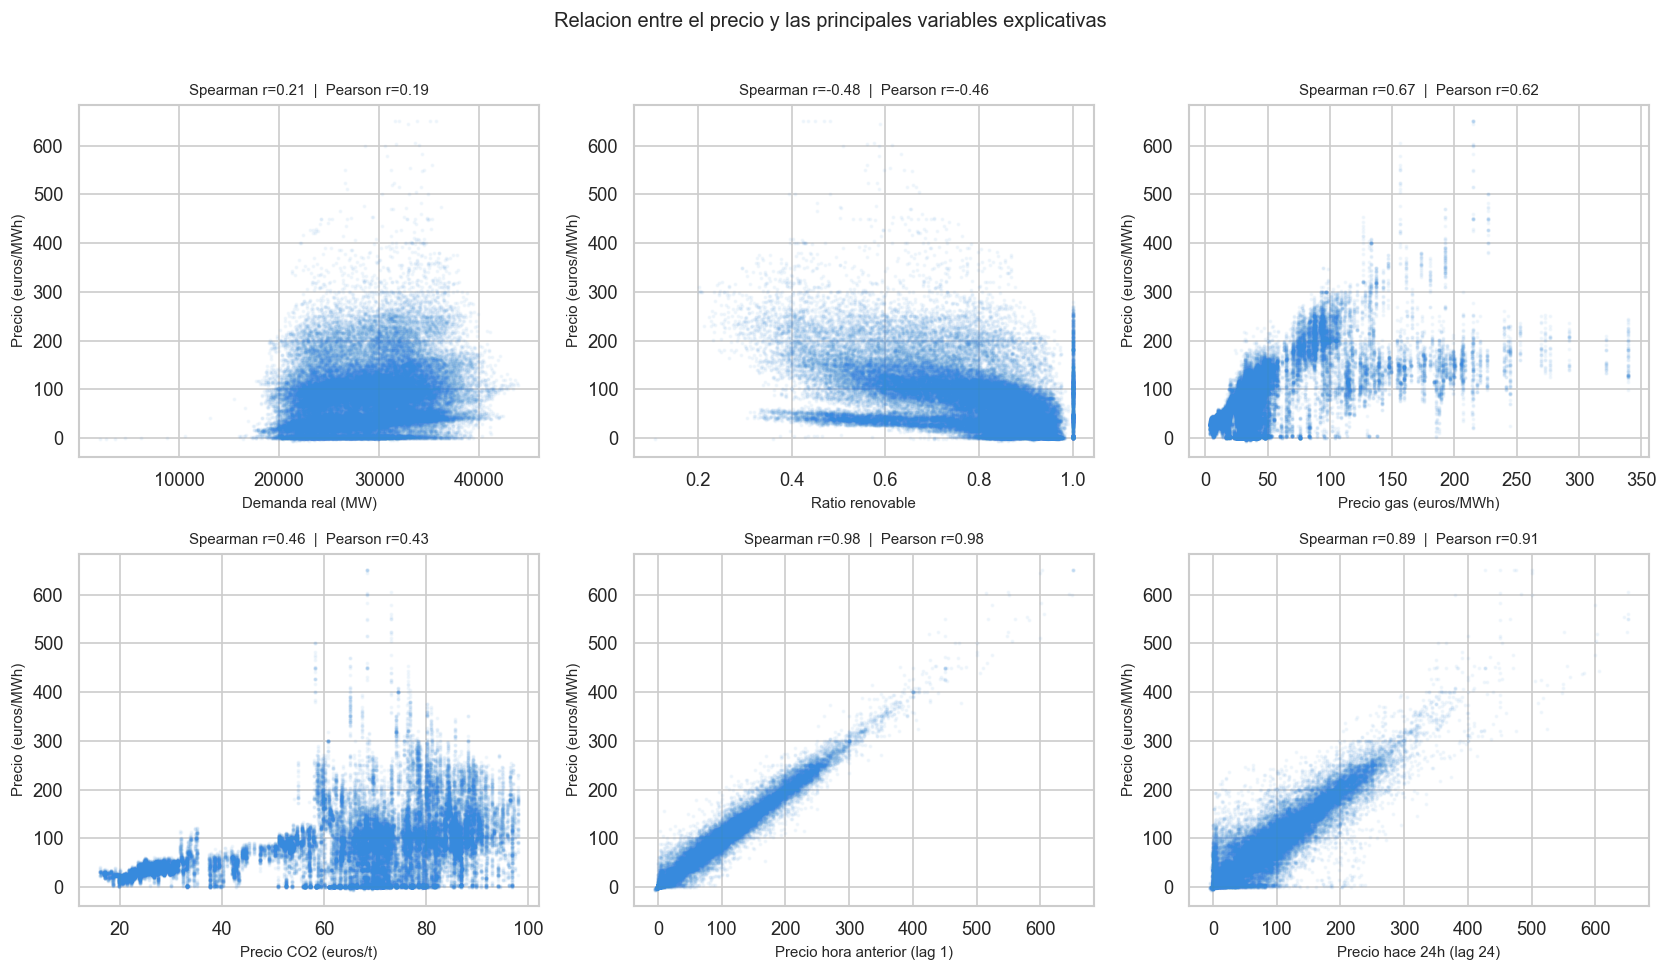

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vars_plot = [
    ('Real', 'Demanda real (MW)'),
    ('renovable_ratio', 'Ratio renovable'),
    ('gas_price', 'Precio gas (euros/MWh)'),
    ('co2_price', 'Precio CO2 (euros/t)'),
    ('price_lag_1', 'Precio hora anterior (lag 1)'),
    ('price_lag_24', 'Precio hace 24h (lag 24)')
]

for ax, (col, label) in zip(axes.flat, vars_plot):
    ax.scatter(df[col], df['price_spain'], alpha=0.05, s=2, color='#378ADD')
    corr_sp = df[col].corr(df['price_spain'], method='spearman')
    corr_pe = df[col].corr(df['price_spain'], method='pearson')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Precio (euros/MWh)', fontsize=9)
    ax.set_title(f'Spearman r={corr_sp:.2f}  |  Pearson r={corr_pe:.2f}', fontsize=9)

plt.suptitle('Relacion entre el precio y las principales variables explicativas', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig9_scatter_variables.png', bbox_inches='tight')
plt.show()

## 12. Autocorrelacion del precio (lags)


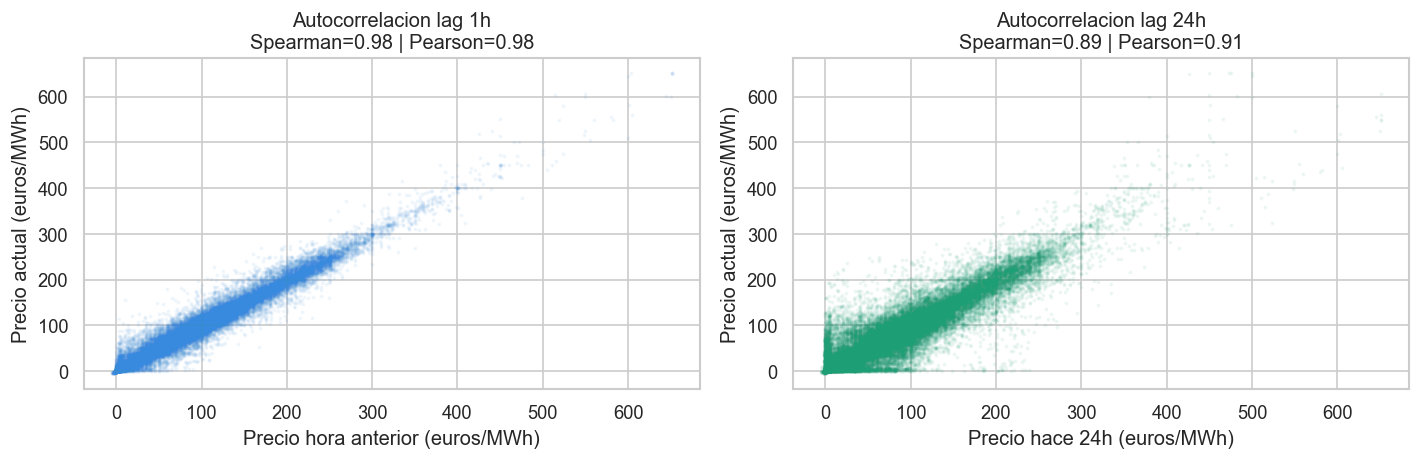

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

corr1_sp = df['price_lag_1'].corr(df['price_spain'], method='spearman')
corr1_pe = df['price_lag_1'].corr(df['price_spain'], method='pearson')
axes[0].scatter(df['price_lag_1'], df['price_spain'], alpha=0.05, s=2, color='#378ADD')
axes[0].set_title(f'Autocorrelacion lag 1h\nSpearman={corr1_sp:.2f} | Pearson={corr1_pe:.2f}')
axes[0].set_xlabel('Precio hora anterior (euros/MWh)')
axes[0].set_ylabel('Precio actual (euros/MWh)')

corr24_sp = df['price_lag_24'].corr(df['price_spain'], method='spearman')
corr24_pe = df['price_lag_24'].corr(df['price_spain'], method='pearson')
axes[1].scatter(df['price_lag_24'], df['price_spain'], alpha=0.05, s=2, color='#1D9E75')
axes[1].set_title(f'Autocorrelacion lag 24h\nSpearman={corr24_sp:.2f} | Pearson={corr24_pe:.2f}')
axes[1].set_xlabel('Precio hace 24h (euros/MWh)')
axes[1].set_ylabel('Precio actual (euros/MWh)')

plt.tight_layout()
plt.savefig('fig10_autocorrelacion.png', bbox_inches='tight')
plt.show()

## 13. Matriz de correlacion de Spearman (principal)


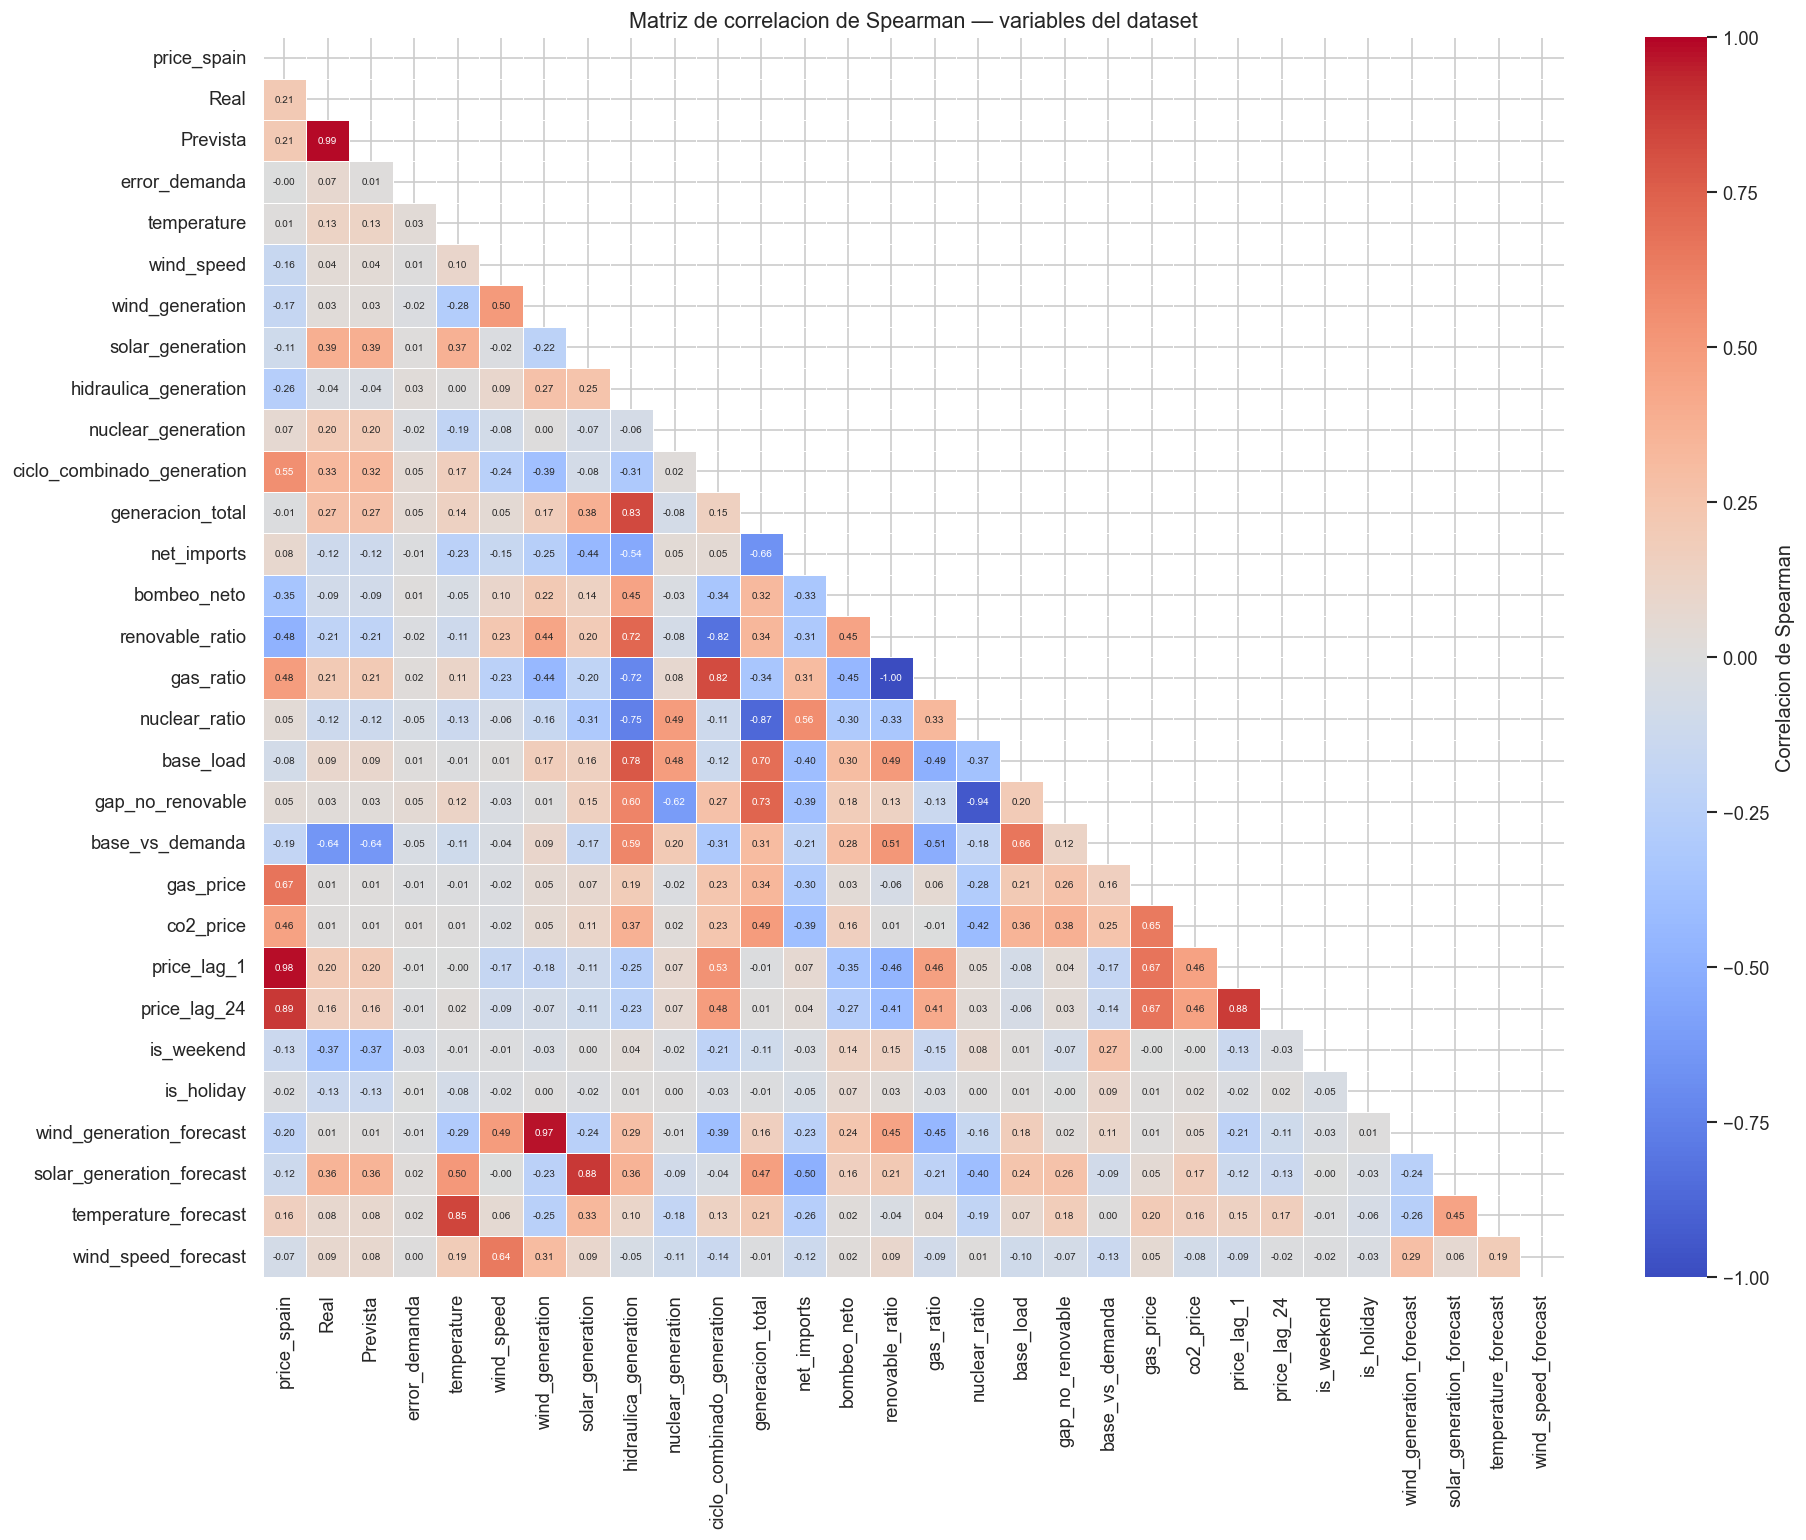

In [21]:
cols_corr = [
    'price_spain', 'Real', 'Prevista', 'error_demanda',
    'temperature', 'wind_speed',
    'wind_generation', 'solar_generation', 'hidraulica_generation',
    'nuclear_generation', 'ciclo_combinado_generation', 'generacion_total',
    'net_imports', 'bombeo_neto',
    'renovable_ratio', 'gas_ratio', 'nuclear_ratio',
    'base_load', 'gap_no_renovable', 'base_vs_demanda',
    'gas_price', 'co2_price',
    'price_lag_1', 'price_lag_24',
    'is_weekend', 'is_holiday',
    'wind_generation_forecast',   
    'solar_generation_forecast',   
    'temperature_forecast',        
    'wind_speed_forecast'          
]

corr_spearman = df[cols_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Correlacion de Spearman'},
            vmin=-1, vmax=1)
ax.set_title('Matriz de correlacion de Spearman — variables del dataset', fontsize=13)
plt.tight_layout()
plt.savefig('fig11_matriz_spearman.png', bbox_inches='tight')
plt.show()

## 14. Matriz de correlacion de Pearson (referencia)


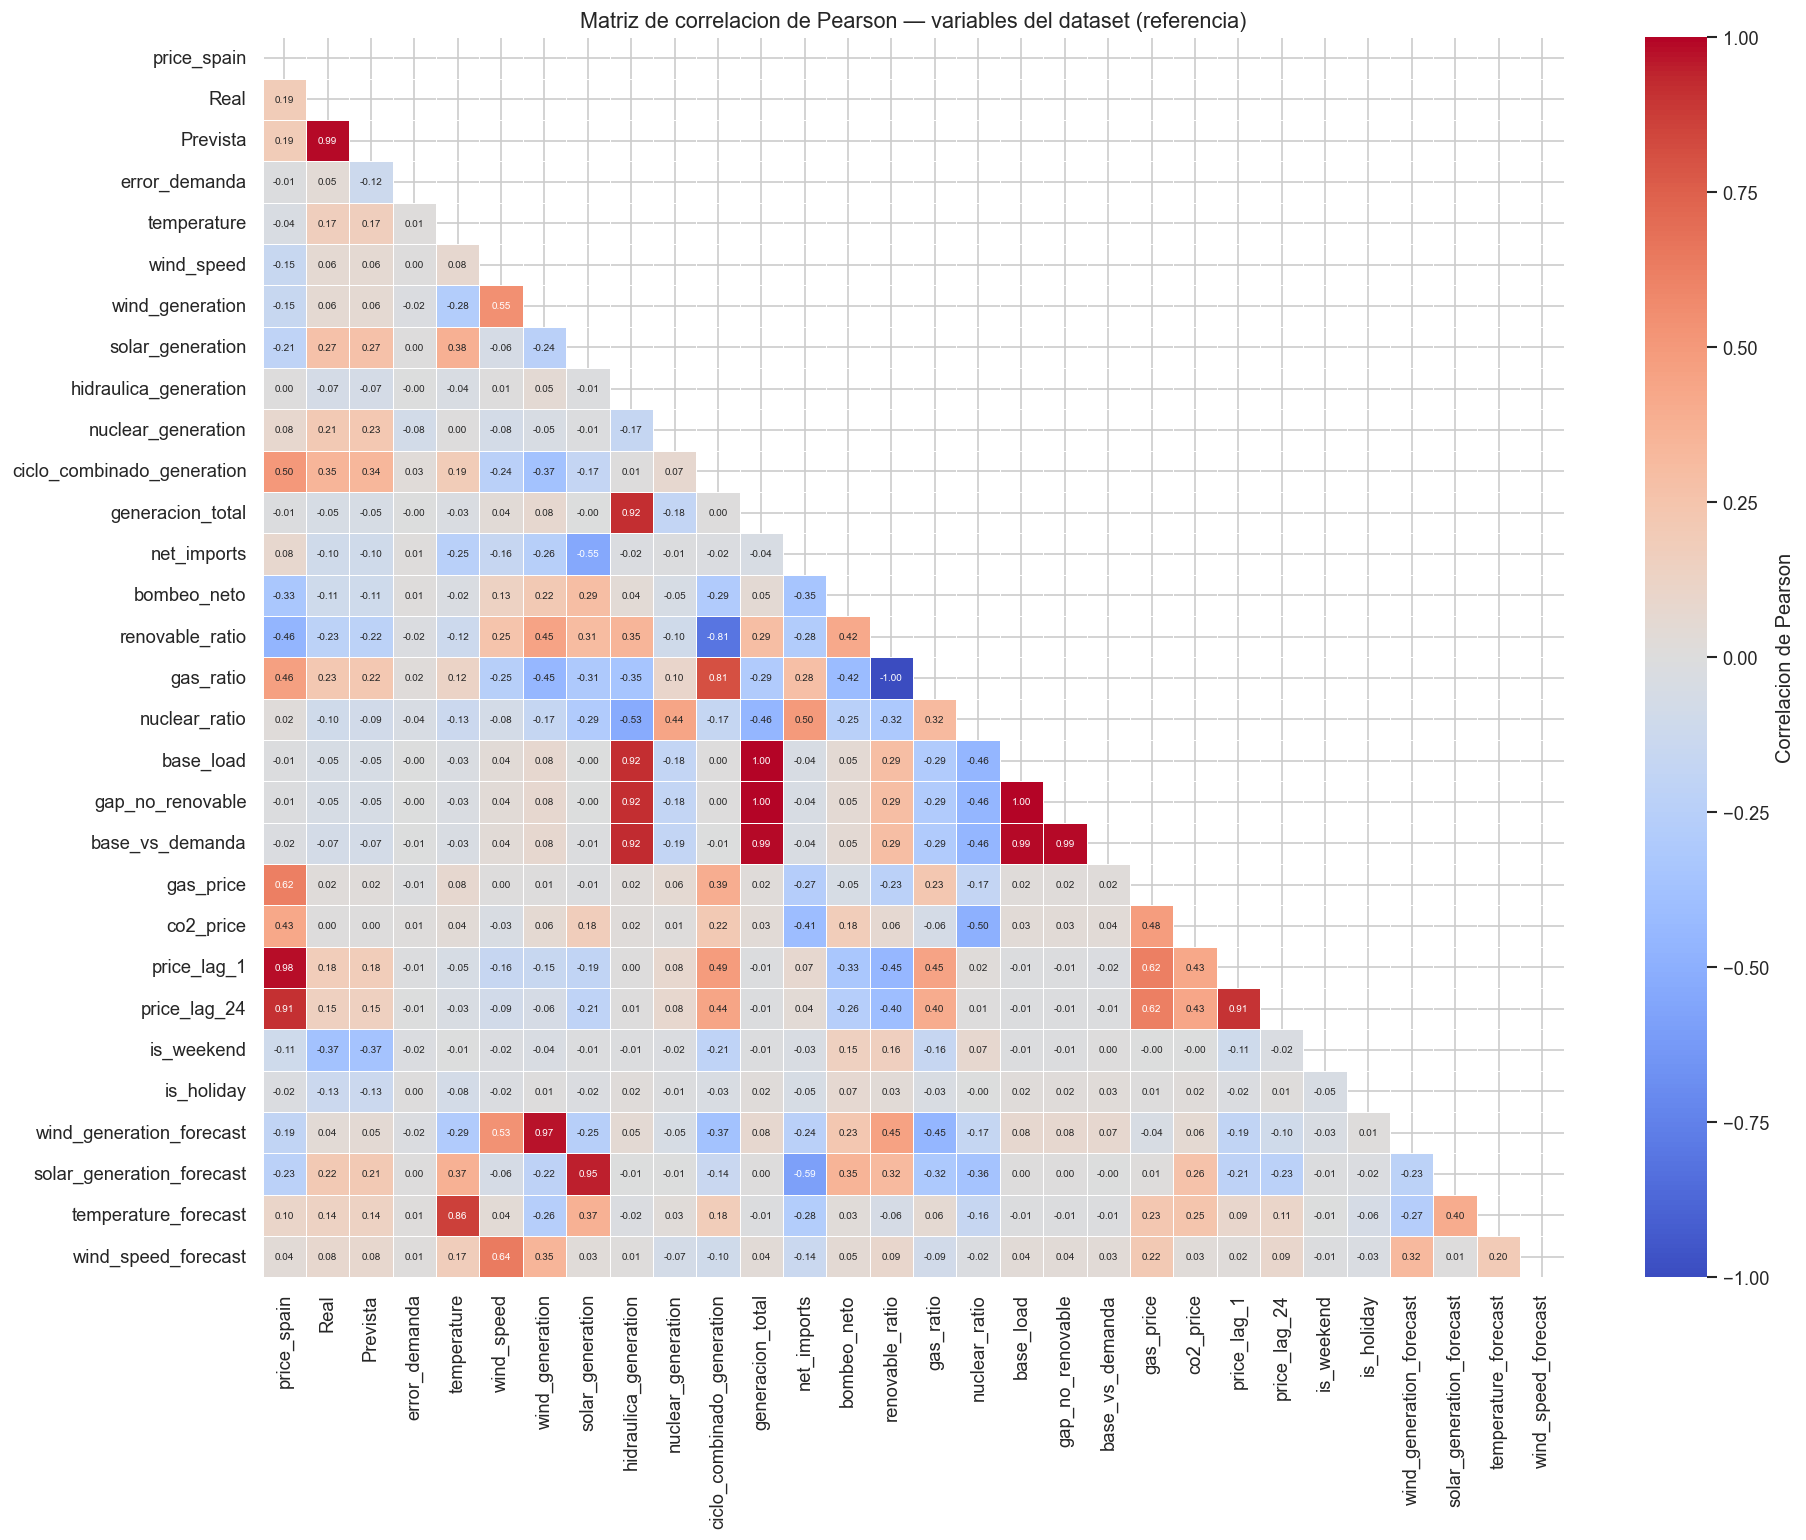

In [22]:
corr_pearson = df[cols_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Correlacion de Pearson'},
            vmin=-1, vmax=1)
ax.set_title('Matriz de correlacion de Pearson — variables del dataset (referencia)', fontsize=13)
plt.tight_layout()
plt.savefig('fig12_matriz_pearson.png', bbox_inches='tight')
plt.show()

## 15. Ranking de correlacion de Spearman con el precio


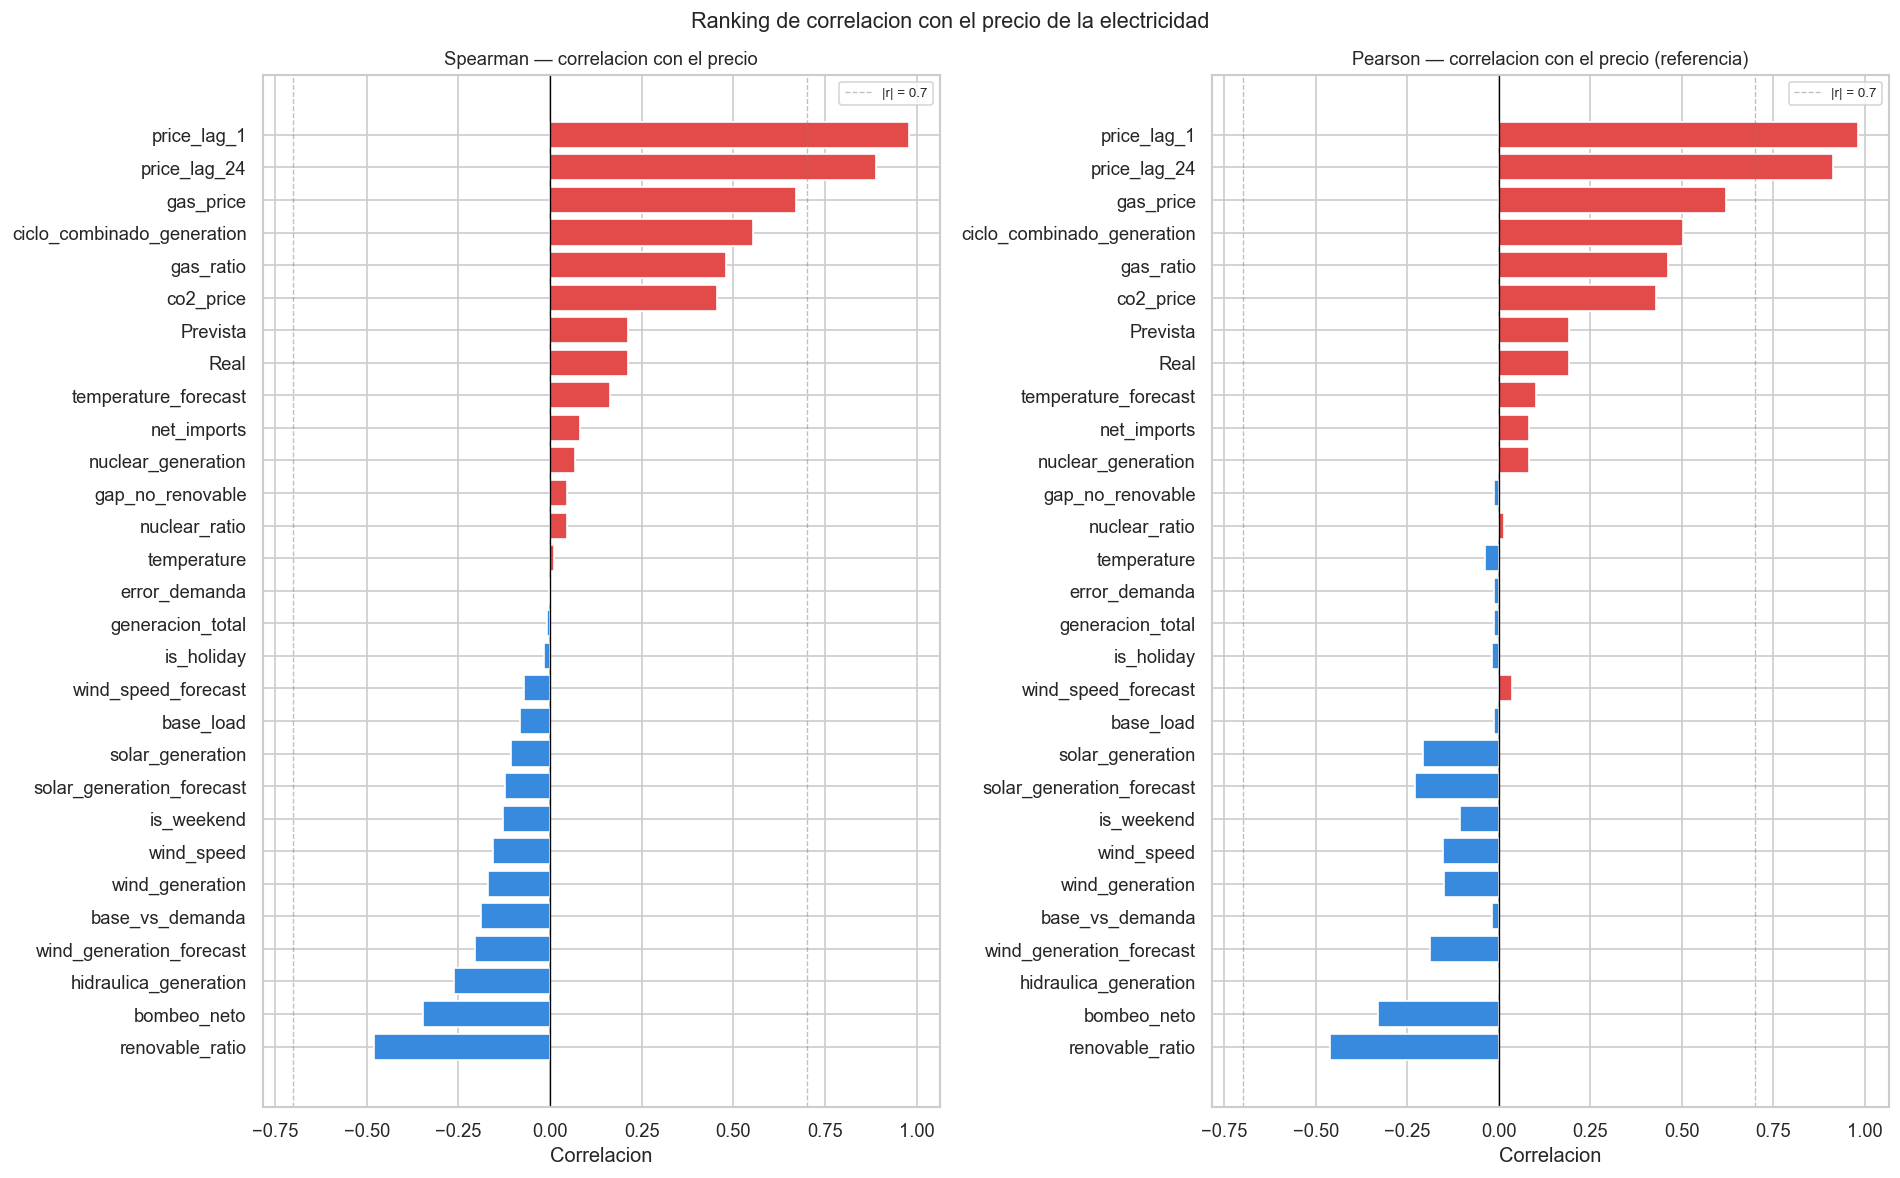

Variables con alta correlacion de Spearman con el precio (|r| > 0.5):
ciclo_combinado_generation    0.554
gas_price                     0.670
price_lag_24                  0.889
price_lag_1                   0.978
Name: price_spain, dtype: float64


In [23]:
corr_precio_sp = corr_spearman['price_spain'].drop('price_spain').sort_values()
corr_precio_pe = corr_pearson['price_spain'].drop('price_spain').reindex(corr_precio_sp.index)

colors = ['#E24B4A' if v > 0 else '#378ADD' for v in corr_precio_sp.values]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Spearman
axes[0].barh(corr_precio_sp.index, corr_precio_sp.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, label='|r| = 0.7')
axes[0].axvline(-0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_title('Spearman — correlacion con el precio', fontsize=11)
axes[0].set_xlabel('Correlacion')
axes[0].legend(fontsize=8)

# Pearson
colors_pe = ['#E24B4A' if v > 0 else '#378ADD' for v in corr_precio_pe.values]
axes[1].barh(corr_precio_pe.index, corr_precio_pe.values, color=colors_pe, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, label='|r| = 0.7')
axes[1].axvline(-0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('Pearson — correlacion con el precio (referencia)', fontsize=11)
axes[1].set_xlabel('Correlacion')
axes[1].legend(fontsize=8)

plt.suptitle('Ranking de correlacion con el precio de la electricidad', fontsize=13)
plt.tight_layout()
plt.savefig('fig13_ranking_correlacion.png', bbox_inches='tight')
plt.show()

print('Variables con alta correlacion de Spearman con el precio (|r| > 0.5):')
print(corr_precio_sp[abs(corr_precio_sp) > 0.5].round(3))

## 16. Deteccion de multicolinealidad entre features


In [24]:
features = [c for c in cols_corr if c != 'price_spain']
corr_feat_sp = corr_spearman.loc[features, features]

alta_corr = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        r = corr_feat_sp.iloc[i, j]
        if abs(r) > 0.85:
            alta_corr.append((features[i], features[j], round(r, 3)))

print('Pares de variables con correlacion de Spearman > 0.85 (posible multicolinealidad):')
print(f'{"Variable 1":<35} {"Variable 2":<35} {"r":>6}')
print('-' * 80)
for v1, v2, r in sorted(alta_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'{v1:<35} {v2:<35} {r:>6.3f}')

Pares de variables con correlacion de Spearman > 0.85 (posible multicolinealidad):
Variable 1                          Variable 2                               r
--------------------------------------------------------------------------------
renovable_ratio                     gas_ratio                           -1.000
Real                                Prevista                             0.991
wind_generation                     wind_generation_forecast             0.969
nuclear_ratio                       gap_no_renovable                    -0.940
solar_generation                    solar_generation_forecast            0.884
price_lag_1                         price_lag_24                         0.879
generacion_total                    nuclear_ratio                       -0.872


## 16b. Validacion de variables previstas: real vs forecast


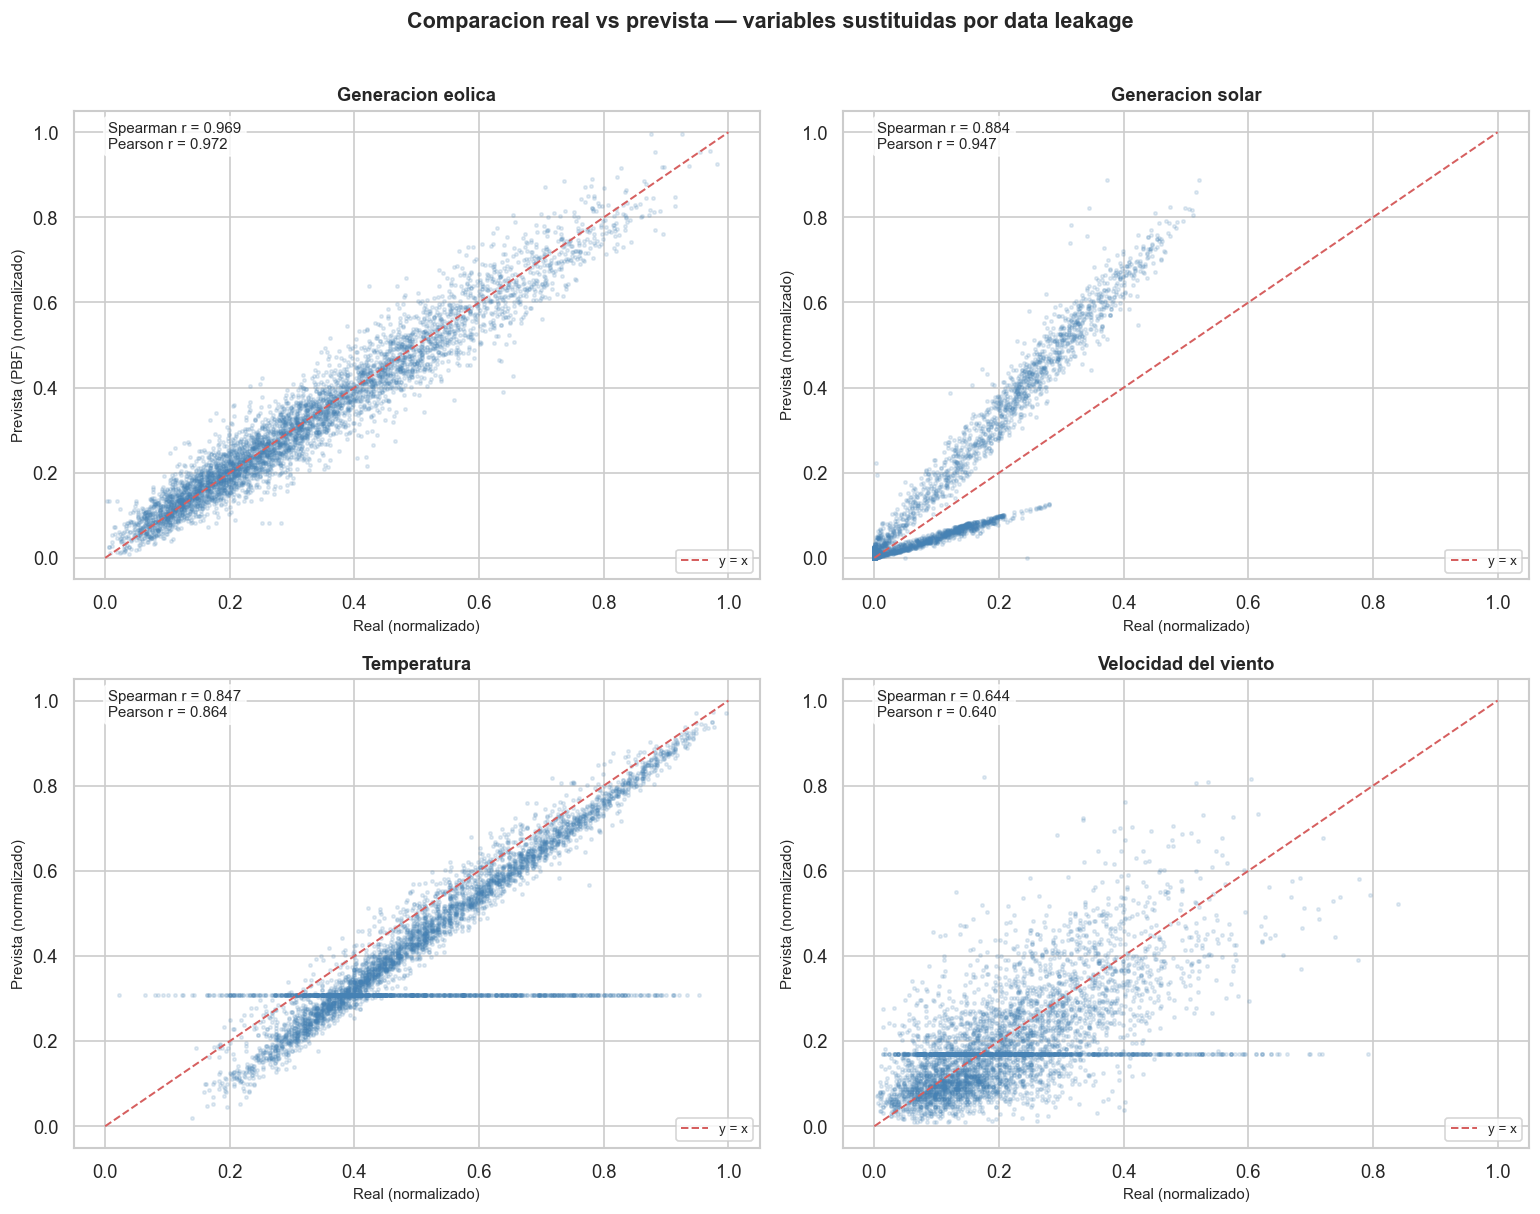

fig14_real_vs_forecast.png guardado


In [25]:
from scipy import stats

pares = [
    ('wind_generation',  'wind_generation_forecast',  'Generacion eolica',         'Real',  'Prevista (PBF)'),
    ('solar_generation', 'solar_generation_forecast', 'Generacion solar',          'Real',  'Prevista'),
    ('temperature',      'temperature_forecast',      'Temperatura',               'Real',  'Prevista'),
    ('wind_speed',       'wind_speed_forecast',       'Velocidad del viento',      'Real',  'Prevista'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (col_real, col_prev, titulo, label_real, label_prev) in zip(axes, pares):
    x = df[col_real].dropna()
    y = df[col_prev].loc[x.index].dropna()
    idx = x.index.intersection(y.index)
    x, y = x.loc[idx], y.loc[idx]

    # Normalizar 0-1
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    r_sp, _ = stats.spearmanr(x, y)
    r_pe, _ = stats.pearsonr(x, y)

    # Muestra aleatoria
    sample = min(5000, len(x_norm))
    rng = np.random.default_rng(42)
    idx_s = rng.choice(len(x_norm), sample, replace=False)

    ax.scatter(x_norm.iloc[idx_s], y_norm.iloc[idx_s], alpha=0.15, s=4, color='steelblue')

    # Linea 1:1
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.2, label='y = x')

    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{label_real} (normalizado)', fontsize=9)
    ax.set_ylabel(f'{label_prev} (normalizado)', fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.text(0.05, 0.92,
            f'Spearman r = {r_sp:.3f}\nPearson r = {r_pe:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=8)

fig.suptitle('Comparacion real vs prevista — variables sustituidas por data leakage',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig14_real_vs_forecast.png', dpi=120, bbox_inches='tight')
plt.show()
print('fig14_real_vs_forecast.png guardado')


## 17. Feature selection — variables finales


In [26]:
vars_eliminadas = {
    'Programada': 'Alta correlacion con Prevista y Real (Spearman r > 0.99)',
    'generacion_total': 'Suma de las variables de generacion individuales (redundante)',
    'consumo_bombeo': 'Componente de bombeo_neto — redundante con bombeo_neto',
    'turbinacion_bombeo': 'Componente de bombeo_neto — redundante con bombeo_neto',
    'base_load': 'Alta correlacion con Real y generacion_total',
    'day_sin': 'Capturado por dayofweek e is_weekend',
    'day_cos': 'Capturado por dayofweek e is_weekend',
    'month_sin': 'Capturado por month',
    'month_cos': 'Capturado por month',
    'gas_ratio': 'Multicolinealidad perfecta con renovable_ratio (Spearman r = -1.0) — se conserva renovable_ratio por mayor interpretabilidad',
    'Real': 'Data leakage — la demanda real no esta disponible en el momento de prediccion, se conserva Prevista',
    'gap_no_renovable': 'Alta correlacion con nuclear_ratio (Spearman r = -0.94) — capturado por las variables de generacion individuales',
    'wind_generation': 'Data leakage — generacion eolica real no disponible en momento de prediccion, se usa wind_generation_forecast',
    'solar_generation': 'Data leakage — generacion solar real no disponible en momento de prediccion, se usa solar_generation_forecast',
    'temperature': 'Data leakage — temperatura real no disponible en momento de prediccion, se usa temperature_forecast',
    'wind_speed': 'Data leakage — velocidad del viento real no disponible en momento de prediccion, se usa wind_speed_forecast',
}

print('Variables eliminadas por multicolinealidad o redundancia:')
print(f'{"Variable":<30} {"Motivo"}')
print('-'*80)
for v, motivo in vars_eliminadas.items():
    print(f'{v:<30} {motivo}')

vars_finales = [c for c in features if c not in vars_eliminadas]
print(f'\nVariables finales seleccionadas: {len(vars_finales)}')
for v in vars_finales:
    print(f'  - {v}')

Variables eliminadas por multicolinealidad o redundancia:
Variable                       Motivo
--------------------------------------------------------------------------------
Programada                     Alta correlacion con Prevista y Real (Spearman r > 0.99)
generacion_total               Suma de las variables de generacion individuales (redundante)
consumo_bombeo                 Componente de bombeo_neto — redundante con bombeo_neto
turbinacion_bombeo             Componente de bombeo_neto — redundante con bombeo_neto
base_load                      Alta correlacion con Real y generacion_total
day_sin                        Capturado por dayofweek e is_weekend
day_cos                        Capturado por dayofweek e is_weekend
month_sin                      Capturado por month
month_cos                      Capturado por month
gas_ratio                      Multicolinealidad perfecta con renovable_ratio (Spearman r = -1.0) — se conserva renovable_ratio por mayor interpretabilidad


## 18. Guardar dataset final con variables seleccionadas

In [27]:
# Eliminar variables redundantes
vars_eliminadas_list = list(vars_eliminadas.keys())
df_final = df.drop(columns=[c for c in vars_eliminadas_list if c in df.columns])
df_final['hidraulica_generation'] = df_final['hidraulica_generation'].clip(upper=17000)
df_final = df_final.drop(columns=['year', 'ren_bin'], errors='ignore')

# Resetear índice para que datetime vuelva a ser columna
df_final = df_final.reset_index()

print(f'Variables originales: {df.shape[1]}')
print(f'Variables eliminadas: {len(vars_eliminadas_list)}')
print(f'Variables finales: {df_final.shape[1]}')
print()
print('Columnas del dataset final:')
print(list(df_final.columns))

# Guardar
df_final.to_csv('dataset_model_ready.csv', index=False)
print('\nDataset guardado como dataset_model_ready.csv')

Variables originales: 44
Variables eliminadas: 16
Variables finales: 27

Columnas del dataset final:
['datetime', 'hour', 'dayofweek', 'month', 'price_spain', 'Prevista', 'error_demanda', 'hidraulica_generation', 'nuclear_generation', 'ciclo_combinado_generation', 'net_imports', 'bombeo_neto', 'renovable_ratio', 'nuclear_ratio', 'hour_sin', 'hour_cos', 'price_lag_1', 'price_lag_24', 'is_weekend', 'is_holiday', 'gas_price', 'co2_price', 'wind_generation_forecast', 'solar_generation_forecast', 'temperature_forecast', 'wind_speed_forecast', 'base_vs_demanda']

Dataset guardado como dataset_model_ready.csv
